In [78]:
import os
import sys
import gc
import base64
import pickle
import itertools
from io import BytesIO
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from functools import reduce

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, mutual_info_classif
from scipy.stats import kruskal
import tensorflow as tf
from cycler import cycler
from matplotlib.colors import to_hex

In [2]:
# ['ori_curves',
#   'ori_curves_avg',
#   'original_fitted_full',
#   'original_fitted_stretched',
#   'cleaned_std_fitted_full',
#   'cleaned_std_fitted_stretched',
#   'cleaned_lowest_fitted_full',
#   'cleaned_lowest_fitted_stretched',
#   'avg_lowest_fitted_full',
#   'avg_lowest_fitted_stretched',
#   'avg_cleaned_std_lowest_fitted_full',
#   'avg_cleaned_std_lowest_fitted_stretched',
#   'avg_cleaned_lowest_lowest_fitted_full',
#   'avg_cleaned_lowest_lowest_fitted_stretched']

# choose kinetics[:8]

## Data structure

In [ ]:
EXCLUDED_FEATURES = [    
    "pixel_row_idx", "pixel_col_idx", "temp_group_idx", "num_active_pixels_in_temp_group",
    "well_temp_lin2d_mean", "well_2d_temp_npr_mean",
    "5p_sigmoid_fitted", "5p_sigmoid_fitted_dydx",
    "Send", "Send_abs", "Send_fit", "Send_fit_abs",
    "cnn_ae_pw_ds1_label_elbow", "cnn_ae_pw_ds1_label_90", "cnn_ae_pw_ds1_label_95",
    "cnn_ae_glb_ds1_label_elbow", "cnn_ae_glb_ds1_label_90", "cnn_ae_glb_ds1_label_95",
    "lstm_ae_pw_ds1_label_elbow", "lstm_ae_pw_ds1_label_90", "lstm_ae_pw_ds1_label_95",
    "lstm_ae_glb_ds1_label_elbow", "lstm_ae_glb_ds1_label_90", "lstm_ae_glb_ds1_label_95",
    "knn_top_0.85", "knn_top_0.9", "knn_top_0.95",
    "msc_mahal_dist",
    "msc_mahal_dist_msc_linear_0.001", "msc_label_msc_linear_0.001",
    "msc_mahal_dist_msc_baseline_0.001", "msc_label_msc_baseline_0.001",
    "amf_label_amf_important", "amf_label_amf_send_5"
]

FEATURE_GROUPS = [
    ['F0', 'log_F0'],
    ['send_5', 'send_10', 'send_15', 'send_20', 'send_25', 'send_abs_5', 'send_abs_10', 'send_abs_15', 'send_abs_20', 'send_abs_25', 'Send', 'Send_abs', 'Send_fit', 'Send_fit_abs'],
    ['F_max', 'Fm', 'FFI', 'F_range'],
    ['Ct', 'ct_idx'],
    ['Cy0', 'Cs', 'As', 'Sc'],
    ['first_half_distance', 'A1', 'xs', 'xms'],
    ['second_half_distance', 'A2', 'xms', 'xe'],
    ['threshold_distance', 'xs', 'xe'],
    ['peak_shifting_distance', 'xp1', 'xp2'],
    ['distance_asymmetry_index', 'first_half_distance', 'second_half_distance'],
    ['area_asymmetry_index', 'A1', 'A2'],
    ['peak_asymmetry_index', 'd2y_xp1', 'd2y_xp2'],
    ['xms', 'y_xms', 'dy_xms'],
    ['xp1', 'y_xp1', 'dy_xp1', 'd2y_xp1'],
    ['xp2', 'y_xp2', 'dy_xp2', 'd2y_xp2'],
    ['xs', 'y_xs'],
    ['xe', 'y_xe'],
    ['amplitude', 'y_xs', 'y_xe'],
    ['y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'F_max', 'Fm', 'FFI', 'F_range']
]

In [ ]:
exp_root = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data"
exp_folders = sorted([name for name in os.listdir(exp_root) if (os.path.isdir(os.path.join(exp_root, name)) and name not in [".DS_Store"])])
exp_paths = [Path(exp_root, name) for name in exp_folders]

### Data Structure
# 10 dataset
dataset_metadata = {                        
    "name": exp_folders,    
    "Y_well": [],           ##
    "timestamps": [],       ##  
}

# 8 curves
curve_metadata = {
    "name": None,           ##
}

# 10 dataset x 8 curves
dataset = {                         
    "kinetic_features": [],
    "dataset_curves": [],
    "importance_dfs": [],
    "top_combination": [],
}

for exp_path in exp_paths:
    importance_dfs_path = os.path.join(exp_path, "feature_importance_dfs.pkl")
    kinetics_path = os.path.join(exp_path, "initial_kinetics_2.pkl")
    
    with open(importance_dfs_path, 'rb') as f:
        data = pickle.load(f)
    
    dataset_metadata["Y_well"].append(data["Y_well"])
    dataset_metadata["timestamps"].append(data["timestamps"])

    if(curve_metadata['name'] is None):
        curve_metadata['name'] = data["dataset_name"]

    dataset["dataset_curves"].append(data["dataset"])
    dataset["importance_dfs"].append(data["importance_dfs"])
    dataset["top_combination"].append(data["top_combination"])

    with open(kinetics_path, 'rb') as f:
        dataset["kinetic_features"].append(pickle.load(f)[:8])

for i, dataset_name in enumerate(dataset_metadata['name']):
    for j, curve_name in enumerate(curve_metadata['name']):
        dataset["kinetic_features"][i][j]["FFI"] = dataset["dataset_curves"][i][j][:, -1]    
        dataset["kinetic_features"][i][j]["F_range"] = dataset["dataset_curves"][i][j][:, -1] - dataset["dataset_curves"][i][j][:, 0]

In [ ]:
curve_split = {
    'original_curves': ['ori_curves', 'ori_curves_avg'],
    'fitted_curves': ['original_fitted_full', 'original_fitted_stretched'],
    'preprocessed_curves': ['cleaned_std_fitted_full', 'cleaned_std_fitted_stretched'],
    'preprocessed_stretched_curves': ['cleaned_lowest_fitted_full', 'cleaned_lowest_fitted_stretched'],
}

summary = {}

In [ ]:
print(f"curve_metadata")
for k, v in curve_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset_metadata")
for k, v in dataset_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset")
for k, v in dataset.items():
    print(f"{k}: {len(v)} x {len(v[0])}")


curve_metadata
name: 8

dataset_metadata
name: 10
Y_well: 10
timestamps: 10

dataset
kinetic_features: 10 x 8
dataset_curves: 10 x 8
importance_dfs: 10 x 8
top_combination: 10 x 8


In [ ]:
dataset["kinetic_features"][0][0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms',
       'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance',
       'first_half_distance', 'second_half_distance',
       'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2',
       'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0',
       'F0', 'FFI', 'F_range'],
      dtype='object')

## Curve Importance Summary

In [9]:
curve_metadata["feature_rank"] = []
curve_metadata["feature_importance"] = []

for j, curve_name in enumerate(curve_metadata['name']):
    curve_importance_dfs = []
    curve_rank_dfs = []
    
    for i, dataset_name in enumerate(dataset_metadata['name']):
        importance_df = dataset["importance_dfs"][i][j].copy()
        importance_df = importance_df[~importance_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        rank_df = importance_df[['feature']].copy()
        rank_df[dataset_name] = importance_df['importance'].rank(ascending=False, method='min')

        importance_df = importance_df.rename(columns={'importance': dataset_name})
        curve_importance_dfs.append(importance_df)
        curve_rank_dfs.append(rank_df)
        
        
    merged_importance_df = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_importance_dfs)
    curve_metadata["feature_importance"].append(merged_importance_df)

    merged_rank_df = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_rank_dfs)    
    # rank_cols = [col for col in merged_rank_df.columns if col != 'feature']
    # merged_rank_df['median_rank'] = merged_rank_df[rank_cols].median(axis=1)
    # merged_rank_df['mean_rank'] = merged_rank_df[rank_cols].mean(axis=1)
    # merged_rank_df = merged_rank_df.sort_values('median_rank').reset_index(drop=True)
    curve_metadata["feature_rank"].append(merged_rank_df)

## Dataset Importance Summary

In [10]:
dataset_metadata["feature_rank"] = []
dataset_metadata["feature_importance"] = []

for i, dataset_name in enumerate(dataset_metadata['name']):
    dataset_importance_dfs = []
    dataset_rank_dfs = []
    
    for j, curve_name in enumerate(curve_metadata['name']):
        importance_df = dataset["importance_dfs"][i][j].copy()
        importance_df = importance_df[~importance_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        rank_df = importance_df[['feature']].copy()
        rank_df[curve_name] = importance_df['importance'].rank(ascending=False, method='min')

        importance_df = importance_df.rename(columns={'importance': curve_name})
        dataset_importance_dfs.append(importance_df)
        dataset_rank_dfs.append(rank_df)
        
    merged_importance_df = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_importance_dfs)
    dataset_metadata["feature_importance"].append(merged_importance_df)

    merged_rank_df = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_rank_dfs)    
    # rank_cols = [col for col in merged_rank_df.columns if col != 'feature']
    # merged_rank_df['median_rank'] = merged_rank_df[rank_cols].median(axis=1)
    # merged_rank_df['mean_rank'] = merged_rank_df[rank_cols].mean(axis=1)
    # merged_rank_df = merged_rank_df.sort_values('median_rank').reset_index(drop=True)
    dataset_metadata["feature_rank"].append(merged_rank_df)

## All Importance Summary

In [11]:
curve_rank_summary = []
for curve_name, rank_df in zip(curve_metadata['name'], curve_metadata['feature_rank']):
    rank_df_temp = rank_df.copy()
    rank_cols = [col for col in rank_df_temp.columns if col != 'feature']
    rank_df_temp['median_rank'] = rank_df_temp[rank_cols].median(axis=1)

    df = rank_df_temp[['feature', 'median_rank']]
    df = df.rename(columns={'median_rank': curve_name})
    curve_rank_summary.append(df)

summary['curve_feature_median_rank'] = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_rank_summary)
# rank_cols = [col for col in summary['curve_feature_rank'].columns if col != 'feature']
# summary['curve_feature_rank']['median_rank'] = summary['curve_feature_rank'][rank_cols].median(axis=1)
# summary['curve_feature_rank']['mean_rank'] = summary['curve_feature_rank'][rank_cols].mean(axis=1)
# summary['curve_feature_rank'] = summary['curve_feature_rank'].sort_values('median_rank').reset_index(drop=True)

## Rank Viz

In [12]:
def feature_importance_heatmap(df, title="", calculate_summary=False, n_rank=None):
    ranked_df = df.copy()
    if(calculate_summary):
        rank_cols = [col for col in ranked_df.columns if col != 'feature']
        ranked_df['median_rank'] = ranked_df[rank_cols].median(axis=1)
        ranked_df['mean_rank'] = ranked_df[rank_cols].mean(axis=1)
        ranked_df = ranked_df.sort_values('median_rank').reset_index(drop=True)
        if (isinstance(n_rank, int)):
            ranked_df = ranked_df.iloc[:n_rank]
    
    heatmap_df = ranked_df.set_index('feature')

    # fig_height = max(8, len(heatmap_df) * 0.4)
    fig_height = len(heatmap_df) * 0.5
    fig_width = len(heatmap_df.columns) * 1
    plt.figure(figsize=(fig_width, fig_height))

    ax = sns.heatmap(
        heatmap_df, 
        cmap="Greens_r", 
        annot=True,          # Show the actual rank numbers in the boxes
        fmt=".1f",           # Format to 1 decimal place
        linewidths=0.5,      # Add gridlines between cells
        cbar_kws={'label': 'Average Rank (Lower is Better)'}
    )

    plt.title(title, fontweight='bold', pad=20)
    plt.ylabel('Features', fontweight='bold', labelpad=10)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
    plt.close()
    # heatmap_save_path = "feature_rank_heatmap.png"
    # plt.savefig(heatmap_save_path, dpi=300, facecolor='white')
    # print(f"Heatmap successfully saved to {heatmap_save_path}")



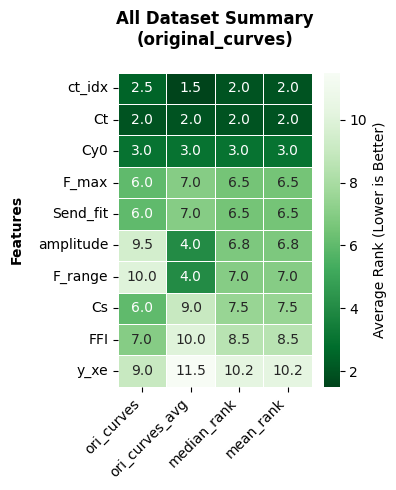

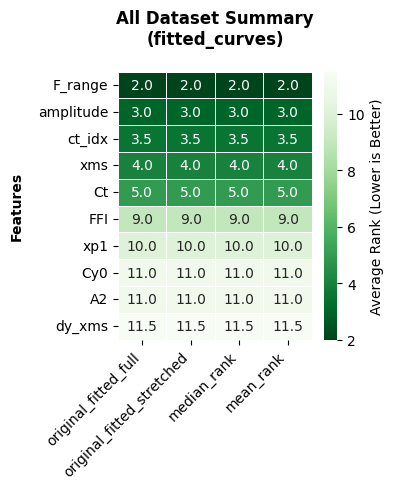

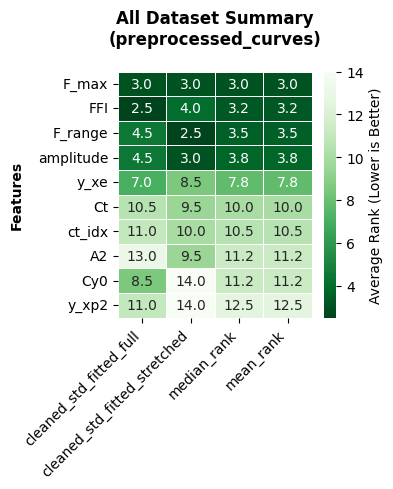

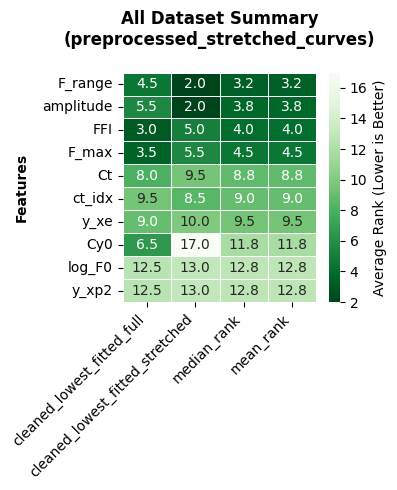

In [13]:
for k, v in curve_split.items():
    split_columns = ['feature'] + v
    feature_importance_heatmap(summary['curve_feature_median_rank'][split_columns], f"All Dataset Summary\n({k})", True, 10)

## Top Features Viz

In [14]:
selected_curve_type = 'ori_curves'
selected_dataset_name = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"

ori_curve_idx = curve_metadata['name'].index(selected_curve_type)
top_10_feature_ori = summary['curve_feature_median_rank'].sort_values(selected_curve_type).reset_index(drop=True).iloc[:10].feature.values
ori_curve_kinetic_features = [kf[ori_curve_idx].copy() for kf in dataset['kinetic_features']]
ori_curve_importances = [imp[ori_curve_idx].copy() for imp in dataset['importance_dfs']]

dataset_idx = dataset_metadata['name'].index(selected_dataset_name)

selected_kf = ori_curve_kinetic_features[dataset_idx].copy()
selected_importance = ori_curve_importances[dataset_idx].sort_values("importance", ascending=False).copy()
selected_y_well = dataset_metadata['Y_well'][dataset_idx]

In [65]:
def plot_feature_visuals(ax_dist, ax_scat, feature, feature_values, y_target, title_text):
    """
    Plots the normalized KDE distribution and the sorted scatter plot for a given feature.
    Automatically handles NaNs and infinite values.
    """
    # Clean Data (NaN / Inf Handling)
    valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
    val_x = feature_values[valid_mask]
    val_y = y_target[valid_mask]
    
    if len(val_x) == 0:
        ax_dist.set_title(f"{title_text}\n(NO VALID DATA)")
        ax_scat.set_title(f"{title_text}\n(NO VALID DATA)")
        return
        
    df_plot = pd.DataFrame({feature: val_x, 'Target': val_y})
    
    # ---------------------------------------------------------
    # PLOT A: Histogram + KDE Distribution
    # ---------------------------------------------------------
    try:
        # Attempt to plot with KDE
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=True, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        
        # Force the KDE line to be black
        for line in ax_dist.lines:
            line.set_color('black')
            line.set_linewidth(1.5)
            
    except Exception:
        # Fallback if KDE fails due to LinAlgError (Zero Variance / Singular Matrix)
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=False, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        # Add a small note that KDE failed for transparency
        ax_dist.text(0.95, 0.95, 'KDE Failed', transform=ax_dist.transAxes, 
                     color='red', fontsize=8, ha='right', va='top')
        
    ax_dist.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_dist.set_xlabel(feature, fontsize=9)
    ax_dist.set_ylabel("Density", fontsize=9)
    
    # ---------------------------------------------------------
    # PLOT B: Sorted Scatter Plot (Event Number)
    # ---------------------------------------------------------
    sort_indices = np.argsort(val_y)
    sorted_y = val_y[sort_indices]
    sorted_feature = val_x[sort_indices]
    x_events = np.arange(len(sorted_feature))
    
    df_scatter = pd.DataFrame({
        'Event Number': x_events,
        feature: sorted_feature,
        'Target': sorted_y
    })
    
    sns.scatterplot(
        data=df_scatter, x='Event Number', y=feature, hue='Target', 
        palette='colorblind', edgecolor=None, s=25, 
        ax=ax_scat, legend=False
    )

    ax_scat.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_scat.set_xlabel("Event Number", fontsize=9)
    ax_scat.set_ylabel(f"{feature} Intensity", fontsize=9)

In [64]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"

dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)

selected_kf = dataset["kinetic_features"][dataset_idx][curve_idx]
selected_importance = dataset["importance_dfs"][dataset_idx][curve_idx].sort_values("importance", ascending=False)
selected_y_well = np.array(dataset_metadata["Y_well"][dataset_idx])


results_list = []

for feature in selected_importance['feature'].values:
    if feature not in EXCLUDED_FEATURES and feature in selected_kf.columns:
        feature_values = selected_kf[feature].values
        
        # NaN and Inf Handling
        valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
        valid_x_1d = feature_values[valid_mask]
        valid_x_2d = valid_x_1d.reshape(-1, 1) 
        valid_y = selected_y_well[valid_mask]
        
        if len(valid_x_1d) > 0 and len(np.unique(valid_y)) > 1:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore") 
                # ANOVA
                f_stat, _ = f_classif(valid_x_2d, valid_y)
                f_score = f_stat[0]
                # Silhouette
                sil_score = silhouette_score(valid_x_2d, valid_y)
        else:
            f_score, sil_score = np.nan, np.nan
            
        results_list.append({
            'feature': feature,
            'anova_score': f_score,
            'silhouette_score': sil_score
        })

metrics_df = pd.DataFrame(results_list)

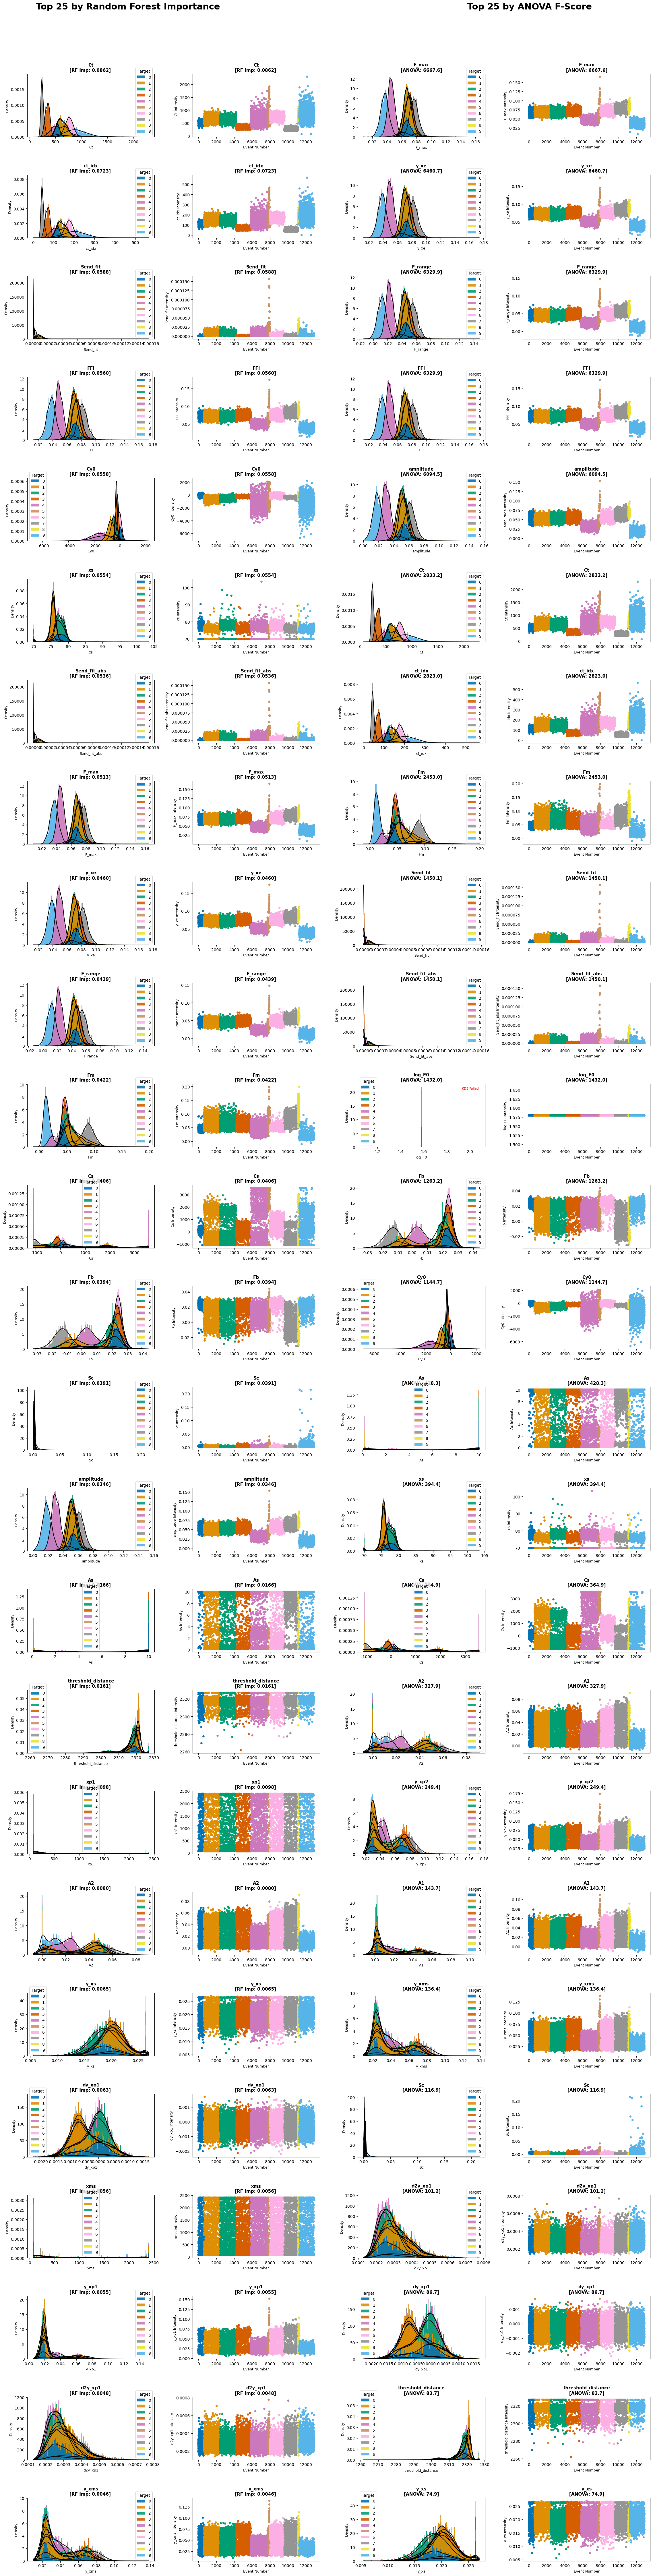

700

In [66]:
top_n_ = 25
valid_importance = selected_importance[selected_importance['feature'].isin(selected_kf.columns)]
top_n_imp = valid_importance.head(top_n_).reset_index(drop=True)
top_n_anova = metrics_df.sort_values(by='anova_score', ascending=False).head(top_n_).reset_index(drop=True)

fig, axes = plt.subplots(top_n_, 4, figsize=(28, top_n_*4.5))
plt.subplots_adjust(hspace=0.6, wspace=0.3) 

for i in range(top_n_):
    # 1. Feature Importance Columns (0 & 1)
    if i < len(top_n_imp):
        imp_feat = top_n_imp.loc[i, 'feature']
        imp_score = top_n_imp.loc[i, 'importance']
        imp_vals = selected_kf[imp_feat].values
        imp_title = f"{imp_feat}\n[RF Imp: {imp_score:.4f}] "
        
        plot_feature_visuals(axes[i, 0], axes[i, 1], imp_feat, imp_vals, selected_y_well, imp_title)
    
    # 2. ANOVA F-Score Columns (2 & 3)
    if i < len(top_n_anova):
        anova_feat = top_n_anova.loc[i, 'feature']
        anova_score = top_n_anova.loc[i, 'anova_score']
        anova_vals = selected_kf[anova_feat].values
        anova_title = f"{anova_feat}\n[ANOVA: {anova_score:.1f}]"
        
        plot_feature_visuals(axes[i, 2], axes[i, 3], anova_feat, anova_vals, selected_y_well, anova_title)

# Add overarching column titles
fig.text(0.25, 0.90, f'Top {top_n_} by Random Forest Importance', ha='center', fontsize=22, fontweight='bold')
fig.text(0.75, 0.90, f'Top {top_n_} by ANOVA F-Score', ha='center', fontsize=22, fontweight='bold')

plt.show()
plt.close(fig)

gc.collect()

In [ ]:

top10_imp = selected_importance.head(10).reset_index(drop=True)
top10_anova = metrics_df.sort_values(by='anova_score', ascending=False).head(10).reset_index(drop=True)

print("\n--- TOP 5 BY RANDOM FOREST IMPORTANCE ---")
print(top10_imp.head(5))
print("\n--- TOP 5 BY ANOVA F-SCORE ---")
print(top10_anova.head(5))

# --- E. Generate 10x4 Grid Visualization ---
print("\n[*] Generating 10x4 Visualization Grid...")
fig, axes = plt.subplots(10, 4, figsize=(28, 45))
plt.subplots_adjust(hspace=0.6, wspace=0.3) 

for i in range(10):
    # 1. Feature Importance Columns (0 & 1)
    if i < len(top10_imp):
        imp_feat = top10_imp.loc[i, 'feature']
        imp_score = top10_imp.loc[i, 'importance']
        imp_vals = selected_kf[imp_feat].values
        imp_title = f"[RF Imp: {imp_score:.4f}] {imp_feat}"
        
        plot_feature_visuals(axes[i, 0], axes[i, 1], imp_feat, imp_vals, selected_y_well, imp_title)
    
    # 2. ANOVA F-Score Columns (2 & 3)
    if i < len(top10_anova):
        anova_feat = top10_anova.loc[i, 'feature']
        anova_score = top10_anova.loc[i, 'anova_score']
        anova_vals = selected_kf[anova_feat].values
        anova_title = f"[ANOVA: {anova_score:.1f}] {anova_feat}"
        
        plot_feature_visuals(axes[i, 2], axes[i, 3], anova_feat, anova_vals, selected_y_well, anova_title)

# Add overarching column titles
fig.text(0.25, 0.90, 'Top 10 by Random Forest Importance', ha='center', fontsize=22, fontweight='bold')
fig.text(0.75, 0.90, 'Top 10 by ANOVA F-Score', ha='center', fontsize=22, fontweight='bold')

# --- F. Save and Cleanup ---
save_path = os.path.join(exp_path, f"top10_feature_comparison_{SELECTED_CURVE_TYPE}.png")
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"[*] Saved visualization to: {save_path}")

plt.close(fig)
import gc
gc.collect()

In [27]:
results_list = []

for feature in selected_importance.feature.values:
    if feature not in EXCLUDED_FEATURES and feature in selected_kf.columns.values:
        # Extract as a 1D array first for easier masking
        feature_values = selected_kf[feature].values
        
        # 1. NaN and Inf Handling: Create a mask for valid numbers
        valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
        
        # Filter both X and Y so their lengths still match perfectly
        valid_x_1d = feature_values[valid_mask]
        valid_x_2d = valid_x_1d.reshape(-1, 1)  # Reshape to 2D for scikit-learn
        valid_y = selected_y_well[valid_mask]
        
        # Ensure we have data left and at least two unique classes for the metrics to work
        if len(valid_x_1d) > 0 and len(np.unique(valid_y)) > 1:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")  # Ignore warnings if a feature is perfectly constant
                
                # --- Calculate ANOVA F-Statistic ---
                f_stat, p_val = f_classif(valid_x_2d, valid_y)
                f_score = f_stat[0]
                
                # --- Calculate Silhouette Score ---
                sil_score = silhouette_score(valid_x_2d, valid_y)
        else:
            # Fallback if filtering removed everything or left only 1 class
            f_score = np.nan
            sil_score = np.nan
            
        # Append the calculated metrics to our list
        results_list.append({
            'feature': feature,
            'anova_score': f_score,
            'silhouette_score': sil_score
        })

# 2. Convert the list of results into a pandas DataFrame
metrics_df = pd.DataFrame(results_list)

# (Optional) Sort the DataFrame by ANOVA score from highest to lowest
metrics_df = metrics_df.sort_values(by='anova_score', ascending=False).reset_index(drop=True)

# View the output
print(metrics_df.head(10))

        feature  anova_score  silhouette_score
0         F_max  6667.580032         -0.017109
1          y_xe  6460.658036         -0.006130
2       F_range  6329.877472         -0.008323
3           FFI  6329.877472         -0.008323
4     amplitude  6094.470917         -0.004194
5            Ct  2833.242806         -0.069682
6        ct_idx  2822.994099         -0.069578
7            Fm  2452.963111         -0.146102
8      Send_fit  1450.128659         -0.216958
9  Send_fit_abs  1450.128658         -0.216958


In [ ]:
for feature in selected_importance.feature.values:
    if feature not in EXCLUDED_FEATURES and feature in selected_kf.columns.values:


(59, 2)

In [28]:
print(metrics_df.sort_values("silhouette_score", ascending=False).head(10))

      feature  anova_score  silhouette_score
42         F0 -1432.000000          0.000000
10     log_F0  1432.000000          0.000000
4   amplitude  6094.470917         -0.004194
1        y_xe  6460.658036         -0.006130
3         FFI  6329.877472         -0.008323
2     F_range  6329.877472         -0.008323
0       F_max  6667.580032         -0.017109
40       Send     9.067656         -0.068047
6      ct_idx  2822.994099         -0.069578
5          Ct  2833.242806         -0.069682


In [ ]:
for feature in selected_importance.feature.values:
    if feature not in EXCLUDED_FEATURES and feature in selected_kf.columns.values:
        feature_values = selected_kf[[feature]].values.flatten()
        feature_values_2d = selected_kf[[feature]].values
    
        # --- 1. Calculate ANOVA F-Statistic ---
        f_stat, p_val = f_classif(feature_values_2d, selected_y_well)
        f_score = f_stat[0]
        
        # --- 2. Calculate Silhouette Score ---
        if len(np.unique(selected_y_well)) > 1:
            sil_score = silhouette_score(feature_values_2d, selected_y_well)
        else:
            sil_score = np.nan
            
        print(f"Feature: {feature: <15} | F-Stat: {f_score: <8.2f} | Silhouette: {sil_score: <6.3f}")

        # # Create a 1x2 figure to hold both plots side-by-side
        # fig, axes = plt.subplots(1, 2, figsize=(22, 6))
        
        # # Temporary DataFrame for easier seaborn plotting
        # df_plot = pd.DataFrame({
        #     feature: feature_values, 
        #     'Target': selected_y_well
        # })
        
        # # ---------------------------------------------------------
        # # PLOT 1: Histogram + KDE Distribution
        # # ---------------------------------------------------------
        # sns.histplot(
        #     data=df_plot, 
        #     x=feature, 
        #     hue='Target', 
        #     bins=150,           # Higher bins for thinner bars
        #     kde=True,           # Adds the smooth density curve
        #     stat='density',     # Normalizes the y-axis (like your reference)
        #     palette='colorblind', 
        #     ax=axes[0],
        #     linewidth=0,        # Removes borders between bars
        #     alpha=0.9
        # )
        
        # # Force the KDE line to be black like in your reference image
        # for line in axes[0].lines:
        #     line.set_color('black')
        #     line.set_linewidth(1.5)

        # axes[0].set_title(f"{feature} - Normalized Distribution", fontweight='bold')
        # axes[0].set_xlabel(feature)
        # axes[0].set_ylabel("Normalized Distribution")
        
        # # ---------------------------------------------------------
        # # PLOT 2: Sorted Scatter Plot (Event Number)
        # # ---------------------------------------------------------
        # # Sort the data by y_well so classes cluster together on the x-axis
        # sort_indices = np.argsort(selected_y_well)
        # sorted_y = selected_y_well[sort_indices]
        # sorted_feature = feature_values[sort_indices]
        # x_events = np.arange(len(sorted_feature))
        
        # df_scatter = pd.DataFrame({
        #     'Event Number': x_events,
        #     feature: sorted_feature,
        #     'Target': sorted_y
        # })
        
        # sns.scatterplot(
        #     data=df_scatter, 
        #     x='Event Number', 
        #     y=feature, 
        #     hue='Target', 
        #     palette='colorblind',
        #     edgecolor=None,     # Removes white borders on dots
        #     s=25,               # Dot size
        #     ax=axes[1],
        #     legend=False        # Hide legend to save space (it's in the first plot)
        # )
        
        # # Optional: Add horizontal red dashed threshold lines 
        # # (Example: drawing lines at the 33rd and 66th percentiles of the feature)
        # # p33, p66 = np.nanpercentile(feature_values, [33, 66])
        # # axes[1].axhline(p33, color='red', linestyle='--')
        # # axes[1].axhline(p66, color='red', linestyle='--')

        # axes[1].set_title(f"{feature} - Sequential Events", fontweight='bold')
        # axes[1].set_xlabel("Event Number")
        # axes[1].set_ylabel(f"{feature} Intensity")
        
        # plt.tight_layout()
        # plt.show()

Feature: Ct              | F-Stat: 2833.24  | Silhouette: -0.070
Feature: ct_idx          | F-Stat: 2822.99  | Silhouette: -0.070
Feature: Send_fit        | F-Stat: 1450.13  | Silhouette: -0.217
Feature: FFI             | F-Stat: 6329.88  | Silhouette: -0.008
Feature: Cy0             | F-Stat: 1144.68  | Silhouette: -0.162
Feature: xs              | F-Stat: 394.41   | Silhouette: -0.142
Feature: Send_fit_abs    | F-Stat: 1450.13  | Silhouette: -0.217
Feature: F_max           | F-Stat: 6667.58  | Silhouette: -0.017
Feature: y_xe            | F-Stat: 6460.66  | Silhouette: -0.006
Feature: F_range         | F-Stat: 6329.88  | Silhouette: -0.008
Feature: Fm              | F-Stat: 2452.96  | Silhouette: -0.146
Feature: Cs              | F-Stat: 364.87   | Silhouette: -0.304
Feature: Fb              | F-Stat: 1263.17  | Silhouette: -0.249
Feature: Sc              | F-Stat: 116.92   | Silhouette: -0.297
Feature: amplitude       | F-Stat: 6094.47  | Silhouette: -0.004
Feature: As              

ValueError: Input X contains NaN.

In [ ]:
ori_curve_kinetic_features

In [ ]:
for i, dataset_name in enumerate(dataset_metadata['name']):
    df = dataset['kinetic_features'][i][ori_curve_idx]
    for j, (curve_name, curve_feature_rank) in enumerate(zip(curve_metadata['name'], curve_metadata['feature_rank'])):
        df[curve_feature_rank]
        original_rank_df = curve_feature_rank[curve_split["original_curves"]].copy()

        rank_cols = [col for col in original_rank_df.columns if col != 'feature']
        original_rank_df['median_rank'] = original_rank_df[rank_cols].median(axis=1)
        original_rank_df = original_rank_df.sort_values('median_rank').reset_index(drop=True)
        print(f"{dataset_name}-{curve_name}-{original_rank_df.iloc[0]}")
        pass